TODO:
- Select model(s)
  - Use temporal validation
- Generate preliminary results
- Create report

In [ ]:
# Packages used for project
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
import scipy.stats as stats
!pip install cartopy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

Mounted at /content/drive/
['data', 'Project Proposal Report.gdoc', 'Project Final Report.gdoc', 'project.ipynb']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.2 MB/s eta 0:00:00


## Wrangling & Exploratory Data Analysis

In [ ]:
# Read in data

data = pd.read_csv('/data/full.csv')
print(f"Data shape: {data.shape}")
data.head()

Data shape: (248684, 20)


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,WESD,WESD_ATTRIBUTES,WESF,WESF_ATTRIBUTES
0,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-20,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN
1,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-21,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN
2,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-22,NaN,NaN,NaN,NaN,21.8,",,N",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-23,NaN,NaN,NaN,NaN,2.3,",,N",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-24,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN


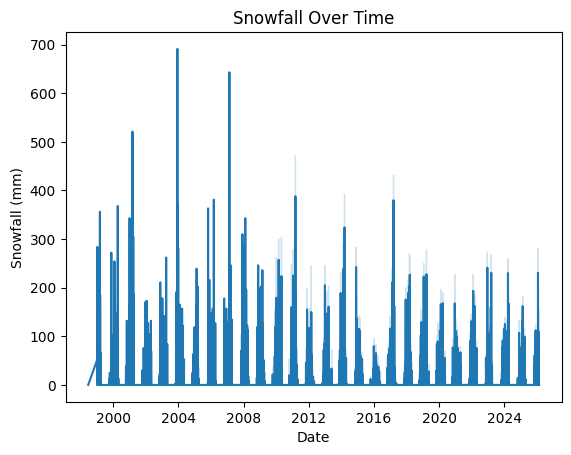

Removed 0 stations with NO snow observations (114 → 114 stations)
Removing 12 additional stations with zero total snowfall across all years
Final station count: 102
Winter data shape: (125222, 12)
Winter years range: 2009 - 2024
Day of year range: 274 - 486
Total records after cleaning: 235,889
Winter records: 125,222
Unique stations: 102
Year range: 2009 - 2025

Columns: ['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'PRCP', 'SNOW', 'SNWD', 'year', 'month', 'day_of_year', 'winter_year']


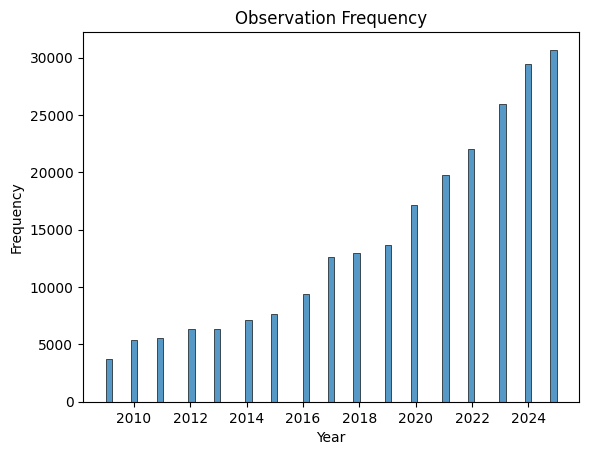

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,PRCP,SNOW,SNWD,year,month,day_of_year,winter_year
284,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,0.0,NaN,2018,11,313,2018
285,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,19.8,NaN,NaN,2018,11,314,2018
286,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,NaN,NaN,2018,11,315,2018
287,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,0.0,NaN,2018,11,316,2018
288,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,13.5,NaN,NaN,2018,11,317,2018


In [ ]:
# Parse DATE and extract useful columns
# Convert DATE string column into datetime object
data['DATE'] = pd.to_datetime(data['DATE'])
data['year'] = data['DATE'].dt.year.astype(int)
data['month'] = data['DATE'].dt.month.astype(int)
data['day_of_year'] = data['DATE'].dt.dayofyear.astype(int)

sns.lineplot(data=data, x='DATE', y='SNOW')
plt.title('Snowfall Over Time')
plt.xlabel('Date')
plt.ylabel('Snowfall (mm)')
plt.show()


# Keep only 2009 and onward
data = data[(data['year'] >= 2009) & (data['year'] <= 2025)].copy()

# Dropping the original DATE column
# no longer need raw DATE string bc we have year/month/day_of_year
data.drop('DATE', axis = 1, inplace = True, errors = 'ignore')

# Each measurement column (SNOW, PRCP, etc.) has a matching
# _ATTRIBUTES column with flags we dont need, so drop them
attr_cols = [c for c in data.columns if c.endswith('_ATTRIBUTES')]
data.drop(columns = attr_cols, inplace = True, errors = 'ignore')

# Dropping columns that are almost entirely NaN
for col in ['DAPR', 'MDPR', 'WESD', 'WESF']:
    if col in data.columns:
        data.drop(columns = col, inplace = True, errors = 'ignore')

# Some stations in dataset do not report snowfall
# identify stations that have at least 1 valid SNOW reading
stations_with_snow = (
    data.groupby('STATION')['SNOW']
    .apply(lambda x: x.notna().sum())
    .reset_index(name = 'snow_obs_count')
)
valid_stations = stations_with_snow.loc[stations_with_snow['snow_obs_count'] > 0, 'STATION']
# calculate how many stations we removed based on the zero filter
n_before = data['STATION'].nunique()
data = data[data['STATION'].isin(valid_stations)].copy()
n_after = data['STATION'].nunique()
print(f"Removed {n_before - n_after} stations with NO snow observations "
      f"({n_before} → {n_after} stations)")

# remove stations whose total seasonal snow is 0 across all recorded winters
# assuming that no VT location will go a winter without snow
station_total_snow = data.groupby('STATION')['SNOW'].sum()
zero_snow_stations = station_total_snow[station_total_snow == 0].index
if len(zero_snow_stations) > 0:
    print(f"Removing {len(zero_snow_stations)} additional stations with "
          f"zero total snowfall across all years")
    data = data[~data['STATION'].isin(zero_snow_stations)].copy()

print(f"Final station count: {data['STATION'].nunique()}")


# 'winter_year' Oct-Dec belong to that years winter
# Jan-May belong to previous years winter
# Oct 2020 -> May 2021 : winter_year = 2020
data['winter_year'] = np.where(data['month'] >= 10,
                               data['year'],
                               data['year'] - 1)

# winter months only
winter_data = data[data['month'].isin([10, 11, 12, 1, 2, 3, 4])].copy()

# Winter 2008 is partial (Oct-Dec 2008 excluded by year>=2009 filter)
# Winter 2025 is incomplete (data ends Feb 2026, missing Mar-Apr)
winter_data = winter_data[~winter_data['winter_year'].isin([2008, 2025])].copy()


# 'day_of_year' that increases through the winter season
# Oct 1 = DOY 274, we want Oct-Dec to keep their normal DOY
# We also want Jan- Apr to have DOY + 365 so the season is continuous
winter_data['day_of_year'] = np.where(
    winter_data['month'] >= 10,
    winter_data['day_of_year'], # Oct-Dec: keep normal DOY 274-365
    winter_data['day_of_year'] + 365 # Jan-Apr: shift forward 366-516
)

# Printing the output for better visualization
print(f"Winter data shape: {winter_data.shape}")
print(f"Winter years range: {winter_data['winter_year'].min()} - {winter_data['winter_year'].max()}")
print(f"Day of year range: {winter_data['day_of_year'].min()} - {winter_data['day_of_year'].max()}")

# Summary of all records after data cleanup
print(f"Total records after cleaning: {len(data):,}")
print(f"Winter records: {len(winter_data):,}")
print(f"Unique stations: {winter_data['STATION'].nunique()}")
print(f"Year range: {winter_data['year'].min()} - {winter_data['year'].max()}")
print(f"\nColumns: {list(data.columns)}")

# Plotting and showing the first few items in the data
sns.histplot(data['year'])
plt.title('Observation Frequency')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()
data.head()

Heavily skewed left. Seems like 2009 is an adequate cutoff year.

# Station Level Seasonal Aggregation

In [ ]:
# Station-Level Seasonal Aggregation
# Collapse daily rows into 1 row per station per winter season
# Each row will contain seasonal totals and statistics as our inputs
# Seasonal totals per station per winter year

# find the 'day of year' of first snow record in each season
# NaN if no snow in a season
def first_snow_doy(group):
    # Day of year of first snowfall > 0 in the season
    snow_days = group[group['SNOW'] > 0]
    if len(snow_days) == 0:
        return np.nan
    # .iloc for getting position in pandas DataFrame
    return snow_days['day_of_year'].iloc[0]

def last_snow_doy(group):
    # Day of year of last snowfall > 0 in the season
    snow_days = group[group['SNOW'] > 0]
    if len(snow_days) == 0:
        return np.nan
    return snow_days['day_of_year'].iloc[-1]

# Sort so that within each station season the days are in chronological order
# This is necessary for first_snow_doy / last_snow_doy to
# get correct dates using .iloc[0] and .iloc[-1]
# Sorting by date within each station season for correct first last
winter_data_sorted = winter_data.sort_values(['STATION', 'winter_year', 'day_of_year'])

# Group every daily observation by (station, station_name, winter_year)
# and compute one summary row per season
seasonal_stats = winter_data_sorted.groupby(['STATION', 'NAME', 'winter_year']).agg(
    total_snow = ('SNOW', lambda x: x.dropna().sum()), # sum only reported days
    # total precipitation (rain + snow water equivalent) in mm
    total_prcp = ('PRCP', 'sum'),
    max_snow_depth = ('SNWD', 'max'),
    # average daily snowpack depth across the season mm
    mean_snow_depth = ('SNWD', 'mean'),
    # count of days where measurable snowfall (> 0 mm) was reported
    snow_days = ('SNOW', lambda x: (x.dropna() > 0).sum()),
    # how many days the station actually reported a SNOW value (non-NaN)
    # Use later to filter out stations with too few observations
    snow_obs_days = ('SNOW', lambda x: x.notna().sum()), # how many days actually reported
    # span in days from first to last observation
    season_length = ('day_of_year', lambda x: x.max() - x.min() + 1),
    latitude = ('LATITUDE', 'first'),
    longitude = ('LONGITUDE', 'first'),
    elevation = ('ELEVATION', 'first'),
).reset_index()

# Compute first and last snow dates separately (groupby + apply)
# then merge them onto the seasonal_stats table
# First and last snow dates per station season
first_last = winter_data_sorted.groupby(['STATION', 'winter_year']).apply(
    lambda x: pd.Series({
        'first_snow_doy': first_snow_doy(x),
        'last_snow_doy': last_snow_doy(x),
    }),
    include_groups = False
).reset_index()

# Left join merging 'STATION' and 'winter_year' and removing unmatched data
seasonal_stats = seasonal_stats.merge(first_last, on = ['STATION', 'winter_year'], how = 'left')

# snow_season_days: number of days between first and last observed snowfall
# A longer snow season means earlier onset or later melt-out
seasonal_stats['snow_season_days'] = (seasonal_stats['last_snow_doy'] - seasonal_stats['first_snow_doy'] + 1)

# Computing snow to precipitation ratio where total_prcp > 0
seasonal_stats['snow_prcp_ratio'] = np.where(
    seasonal_stats['total_prcp'] > 0,
    seasonal_stats['total_snow'] / seasonal_stats['total_prcp'],
    0)

# Drop station seasons with zero total snow
n_before_zero = len(seasonal_stats)
seasonal_stats = seasonal_stats[seasonal_stats['total_snow'] > 0].copy()
print(f"Dropped {n_before_zero - len(seasonal_stats)} station-seasons with "
      f"zero total snow (data coverage artifacts)")




# Require at minimum x many days of SNOW observations in a season
# full Oct–Apr season is ~212 days
MIN_OBS_DAYS = 30
before_filter = len(seasonal_stats)
seasonal_stats = seasonal_stats[
    seasonal_stats['snow_obs_days'] >= MIN_OBS_DAYS
].copy()
after_filter = len(seasonal_stats)
print(f"\nFiltered out {before_filter - after_filter} sparse station-seasons "
      f"(< {MIN_OBS_DAYS} SNOW obs days): {before_filter} → {after_filter}")

# stations ranked by lowest mean seasonal snowfall
station_snow_summary = seasonal_stats.groupby(['STATION', 'NAME']).agg(
    mean_season_snow=('total_snow', 'mean'),
    min_season_snow=('total_snow', 'min'),
    n_seasons=('winter_year', 'count'),
).reset_index().sort_values('mean_season_snow')

print(f"Stations with lowest mean seasonal snowfall")
print(station_snow_summary.head(10).to_string(index = False))


# Showing summary of seasonal stats
print(f"\nSeasonal stats summary:")
print(seasonal_stats[['total_snow', 'total_prcp', 'max_snow_depth', 'snow_days',
                       'snow_season_days', 'snow_prcp_ratio']].describe())

Dropped 58 station-seasons with zero total snow (data coverage artifacts)

Filtered out 49 sparse station-seasons (< 30 SNOW obs days): 692 → 643
Stations with lowest mean seasonal snowfall
    STATION                         NAME  mean_season_snow  min_season_snow  n_seasons
US1VTWS0036        DUXBURY 2.5 SW, VT US          9.020000              0.3          5
US1VTLM0016   MORRISVILLE 1.2 ESE, VT US         40.000000             40.0          1
US1VTFR0029      FLETCHER 0.7 SSW, VT US         59.266667             42.5          3
US1VTCL0019  EAST HARDWICK 0.4 SE, VT US         61.150000              7.0          4
US1VTWS0015    EAST CALAIS 1.5 SW, VT US         68.350000             27.0         14
US1VTFR0027         SHELDON 2.7 N, VT US         70.000000             70.0          1
US1VTWH0019      EAST DOVER 1.8 N, VT US         70.671429             39.7          7
US1VTFR0021       FAIRFAX 4.9 WNW, VT US         74.116667             67.1          6
US1VTFR0026  ENOSBURG FALLS

# Regional Clustering of Stations

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


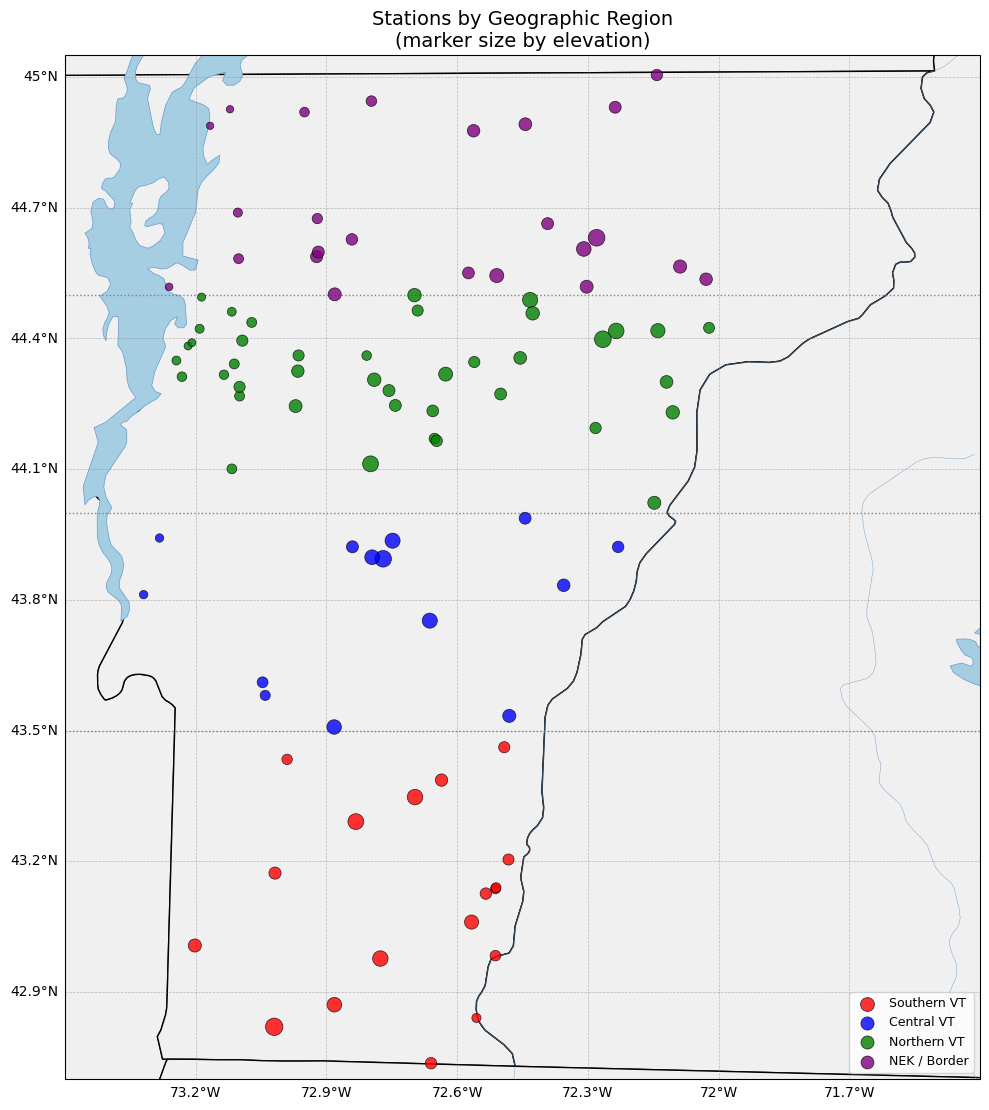

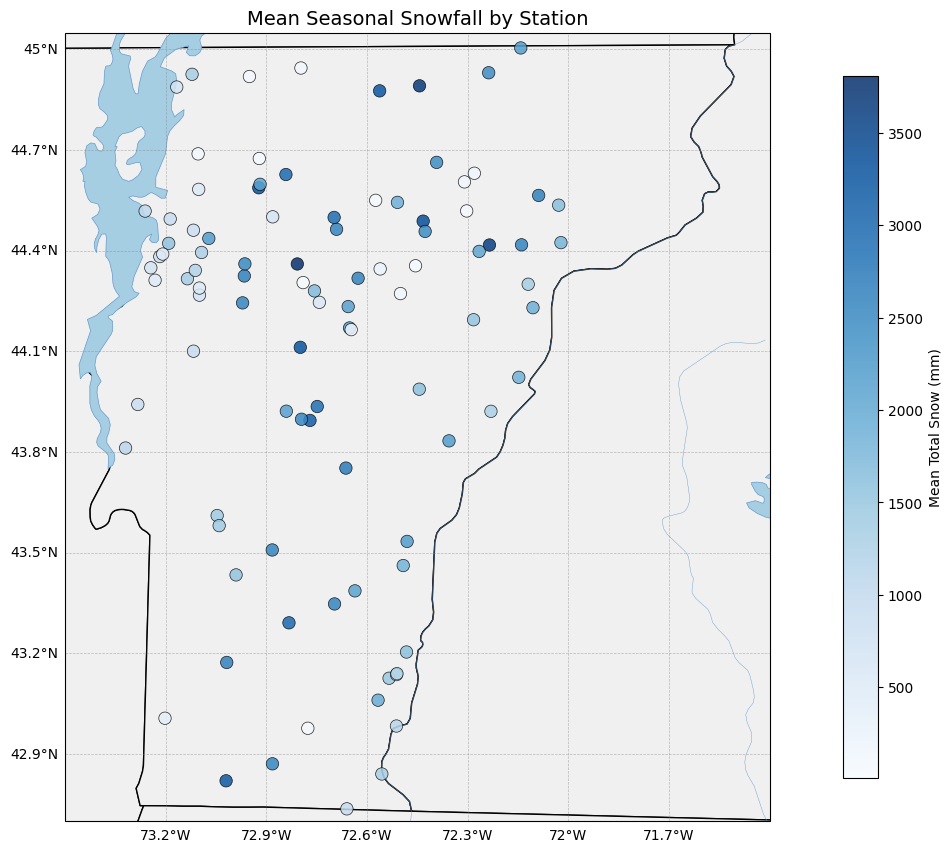


Stations per county region:
county_region_name
Central VT      14
NEK / Border    24
Northern VT     41
Southern VT     18
Name: count, dtype: int64


In [ ]:
# Station metadata for clustering
station_meta = seasonal_stats.groupby('STATION').agg(
    latitude = ('latitude', 'first'),
    longitude = ('longitude', 'first'),
    elevation = ('elevation', 'first'),
    mean_total_snow = ('total_snow', 'mean'),
    name = ('NAME', 'first'),
).reset_index()

# vermont in quarter regions
# Region 0 Southern VT  (lat < 43.50)
# Region 1 Central VT   (43.50 <= lat < 44.00)
# Region 2 Northern VT  (44.00 <= lat < 44.50)
# Region 3 NEK / Border (lat >= 44.50)

def assign_county_region(lat):
    # geographic region based on latitude bands
    if lat < 43.50:
        return 0 # Southern VT
    elif lat < 44.00:
        return 1 # Central VT
    elif lat < 44.50:
        return 2 # Northern VT
    else:
        return 3 # Northeast Kingdom
station_meta['county_region'] = station_meta['latitude'].apply(assign_county_region)

COUNTY_REGION_NAMES = {
    0: 'Southern VT',
    1: 'Central VT',
    2: 'Northern VT',
    3: 'NEK / Border',
}
station_meta['county_region_name'] = station_meta['county_region'].map(COUNTY_REGION_NAMES)




# based on quarter split of VT
station_meta['region'] = station_meta['county_region']

# Merging region labels back to seasonal stats
seasonal_stats = seasonal_stats.merge(
    station_meta[['STATION', 'region', 'county_region_name']],
    on = 'STATION', how = 'left'
)

# Vermont bounding box
# Using cartopy for drawing VT map, scale is currently a little weird
VT_LON_MIN, VT_LON_MAX = -73.50, -71.40
VT_LAT_MIN, VT_LAT_MAX = 42.70, 45.05
# creates a cartopy map zoomed into Vermont
# Adds state borders, land/water shading, and lat/lon grid
def create_vermont_map_axis(fig, position=111):
    # Create matplotlib axis with Vermont outline map background & lat/lon grid
    ax = fig.add_subplot(position, projection=ccrs.PlateCarree())
    ax.set_extent([VT_LON_MIN, VT_LON_MAX, VT_LAT_MIN, VT_LAT_MAX],
                  crs=ccrs.PlateCarree())

    # State boundaries 10m resolution
    ax.add_feature(cfeature.STATES.with_scale('10m'),
                   linewidth=1.0,
                   edgecolor='black',
                   facecolor='#f0f0f0')
    # Land/water coloring for context
    ax.add_feature(cfeature.LAND.with_scale('10m'),
                   facecolor="#f9f9f8",
                   zorder=0)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),
                   facecolor='#a6cee3',
                   edgecolor='#6699cc',
                   linewidth=0.5)
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),
                   edgecolor='#6699cc',
                   linewidth=0.3)

    # Lat/lon gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray',
                      alpha=0.5, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False

    return ax


# Station clusters on Vermont map
fig = plt.figure(figsize=(10, 12))
ax = create_vermont_map_axis(fig)

colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}
for region_id, region_name in COUNTY_REGION_NAMES.items():
    subset = station_meta[station_meta['county_region'] == region_id]
    ax.scatter(subset['longitude'], subset['latitude'],
               c = colors[region_id], label = region_name,
               s = subset['elevation'] / 5 + 20, alpha = 0.8,
               edgecolors = 'black', linewidth = 0.5,
               transform = ccrs.PlateCarree(), zorder = 5)

ax.set_title('Stations by Geographic Region\n(marker size by elevation)', fontsize=14)
ax.legend(loc = 'lower right', fontsize=9)
# latitude boundaries
for lat_line in [43.50, 44.00, 44.50]:
    ax.plot([VT_LON_MIN, VT_LON_MAX], [lat_line, lat_line],
            color='gray', linestyle=':', linewidth=1,
            transform=ccrs.PlateCarree())
plt.tight_layout()
plt.show()

# Stations colored by mean snowfall, blue color intensity indicates
# how much snow a station gets on average per season
# Mean seasonal snowfall
fig = plt.figure(figsize = (10, 12))
ax = create_vermont_map_axis(fig)
scatter2 = ax.scatter(
    station_meta['longitude'], station_meta['latitude'],
    c = station_meta['mean_total_snow'], cmap = 'Blues', s = 80,
    alpha = 0.85, edgecolors = 'black', linewidth = 0.5,
    transform = ccrs.PlateCarree(), zorder = 5)
ax.set_title('Mean Seasonal Snowfall by Station', fontsize  =14)
# make a legend to show what color intensity represents
plt.colorbar(scatter2, ax=ax, label = 'Mean Total Snow (mm)', shrink = 0.6, pad = 0.08)
plt.tight_layout()
plt.show()

print(f"\nStations per county region:")
print(station_meta['county_region_name'].value_counts().sort_index())

# Set Up Features to use, more data cleaning

In [ ]:
# models need past data for predictions
# We create "lag features" to give data to each model
# from the previous 1, 2, and 3 winters at each station
# Lag Features:
#   snow_lag1 = last winter total snowfall
#   snow_lag2 = two winters ago
#   snow_lag3 = three winters ago
#   same pattern for precipitation, snow_days, and snow/prcp ratio
# Rolling Averages:
#   snow_roll3 = average of the previous 3 winters snowfall
#   snow_roll5 = average of the previous 5 winters snowfall
#   These smooth out year to year noise and get short term trends
# Target prediction var: total_snow

LAG_YEARS = [1, 2, 3]

# Dict maps output column prefix to source column for lagging by yrs
LAG_COLS = {
    "snow": "total_snow",
    "prcp": "total_prcp",
    "snow_days": "snow_days",
    "ratio": "snow_prcp_ratio",
}

# all feature columns getting fed into models
# includes station location, time trend, 12 lag columns (4 vars x 3 lags)
# and 2 rolling averages = 19 features total

FEATURE_COLS = [
    "latitude", "longitude", "elevation", "region",  # station metadata
    "year_numeric", # trend year offset
    *[f"{name}_lag{lag}" for lag in LAG_YEARS for name in LAG_COLS], # lag features naming
    "snow_roll3", "snow_roll5", # rolling snow averages for 3yr or 5yr
]

# target prediction
TARGET_COL = "total_snow"

# fix features
# Sort by station then year so that shift(n) correctly grabs
# the value from n winters ago for the same station
# sort so lags and rolling windows are computed in chronological order per station
ml_data = seasonal_stats.sort_values(["STATION", "winter_year"]).copy()
# For each variable (snow, prcp, snow_days, ratio) and each lag (1, 2, 3) create a new column
# groupby("STATION").shift(lag) moves each station's values backward by `lag` rows (lag winters)
# lag features shift each source column back 1, 2, 3 winters per station
for name, source_col in LAG_COLS.items():
    for lag in LAG_YEARS:
        ml_data[f"{name}_lag{lag}"] = ml_data.groupby("STATION")[source_col].shift(lag)

# shift(1) excludes the current year, prevents data leakage cant
# use this winter snowfall to predict this winter's snowfall
# rolling(3, min_periods=1) computes mean of up to 3 prior values
# min_periods=1 means if only 1 or 2 prior years exist, it still computes
# an average from whatever is available (necessary for starting years)
# rolling averages shift(1) first so current year is never included in its own average
ml_data["snow_roll3"] = ml_data.groupby("STATION")["total_snow"].transform(
    lambda x: x.shift(1).rolling(3, min_periods = 1).mean()
)
ml_data["snow_roll5"] = ml_data.groupby("STATION")["total_snow"].transform(
    lambda x: x.shift(1).rolling(5, min_periods = 1).mean()
)

# integer offset from the earliest winter in the dataset.
# if the dataset starts at winter_year=2009, then 2009->0, 2010->1, ....
# gives model a simple linear trend variable to capture long term changes in snowfall
# year offset from the earliest winter in the dataset
ml_data["year_numeric"] = ml_data["winter_year"] - ml_data["winter_year"].min()

# The first 1-3 years per station will have NaN lags / no prior data to shift from
# dropna removes those rows so model only trains on complete records
# drop any row missing a feature or the target, which is expected for first 1-3 years
ml_ready = ml_data.dropna(subset = FEATURE_COLS + [TARGET_COL]).copy()


print(f"ML ready samples: {len(ml_ready)}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Winter year range: {ml_ready['winter_year'].min()} - {ml_ready['winter_year'].max()}")

ML ready samples: 387
Features: 19
Winter year range: 2012 - 2024


# Train Test Split and Model Instances, Cross Validation

In [ ]:
# as this is Timeseries data, we cannot randomly split rows
# Future data cant appear in training
#   Train: all winters except the last 3
#   Test: the last 3 winters
# We also run Time Series Cross Validation TSCV on training set
# to get an estimate of model performance

# Linear Regression - simple baseline, assumes linear relationship
# Ridge Regression  - linear + L2 penalty (shrinks large coefficients)
# Lasso Regression  - linear + L1 penalty (can zero out features)
# Random Forest     - ensemble of decision trees (bagging)
# Gradient Boosting - sequential trees that correct prior errors


# train on earlier years, test on recent ones
# split everything before last 3 winter years = train last 3 = test
max_year = ml_ready['winter_year'].max()
test_years = [max_year - 2, max_year - 1, max_year]
# training is not(~) in test years we define above
train_mask = ~ml_ready['winter_year'].isin(test_years)
test_mask = ml_ready['winter_year'].isin(test_years)

# Extract feature matrices X and target vectors y as numpy arrays
# .values converts from DataFrame to raw numpy array for sklearn
X_train = ml_ready.loc[train_mask, FEATURE_COLS].values
y_train = ml_ready.loc[train_mask, TARGET_COL].values
X_test = ml_ready.loc[test_mask, FEATURE_COLS].values
y_test = ml_ready.loc[test_mask, TARGET_COL].values

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Train years: {ml_ready.loc[train_mask, 'winter_year'].min()} - "
      f"{ml_ready.loc[train_mask, 'winter_year'].max()}")
print(f"Test years: {sorted(ml_ready.loc[test_mask, 'winter_year'].unique())}")

# scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# define models to use
models = {
    'Linear Regression': LinearRegression(),
    # Ridge alpha controls regularization strength (higher = more shrinkage)
    'Ridge Regression': Ridge(alpha = 1.0),
    # L1 penalty can drive coefficients to exactly zero
    'Lasso Regression': Lasso(alpha = 1.0, max_iter = 10000),
    # Random Forest 200 trees, max depth 15 to prevent overfitting
    # min_samples_leaf=5 means each leaf node needs at least 5 samples
    # n_jobs=-1 uses all processors
    'Random Forest': RandomForestRegressor(
        n_estimators = 200, max_depth = 15, min_samples_leaf = 5, random_state = 42, n_jobs = -1
    ),
    # Gradient Boosting sequential trees with learning_rate = 0.1
    # Lower learning rate + more trees = better generalization but slower
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators = 200, max_depth = 5, learning_rate = 0.1, random_state = 42
    ),
}



# TimeSeriesSplit with 5 folds, each fold trains on all data up to a
# cutoff point and tests on the next chunk, respecting temporal order
# Example with 5 folds on years 2010-2020:
#   Fold 1: train 2010-2012, test 2013-2014
#   Fold 2: train 2010-2014, test 2015-2016
#   and so on, so training set grows each fold
# Time Series cross validation on training set
# TimeSeriesSplit w 5 folds so ordering stays
tscv = TimeSeriesSplit(n_splits = 5)

# need indices sorted by winter_year for proper temporal CV
train_df = ml_ready.loc[train_mask].sort_values('winter_year').reset_index(drop = True)
X_train_cv = train_df[FEATURE_COLS].values
y_train_cv = train_df[TARGET_COL].values
scaler_cv = StandardScaler()
X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)

print("Time Series Cross Validation 5 folds")
cv_results = {}
for name, model in models.items():
    # Tree models use raw features; linear models use scaled features
    X_cv = X_train_cv_scaled if (not ('Forest' in name or 'Boosting' in name)) else X_train_cv
    # clone(model) creates a fresh copy so each fold starts from scratch
    # scoring = 'neg_root_mean_squared_error': sklearn convention is to negate
    # error metrics so "higher is better", we reverse this below
    scores = cross_val_score(
        clone(model), X_cv, y_train_cv,
        cv = tscv, scoring = 'neg_root_mean_squared_error', n_jobs = -1
    )
    cv_rmse = -scores  # negate because sklearn returns negative RMSE
    cv_results[name] = {
        'CV Mean RMSE': cv_rmse.mean(),
        'CV Std RMSE':  cv_rmse.std(),
    }
    print(f"{name}:  RMSE = {cv_rmse.mean():.2f} +- {cv_rmse.std():.2f}")



# Training and test eval
# Train each model on the full training set and evaluate on the held out test set
#   RMSE: root mean squared error (penalizes large errors more)
#   MAE: mean absolute error (average magnitude of errors)
#   R^2: fraction of variance explained (1.0 = perfect, 0.0 = no better than mean)


results = {}
predictions = {}

for name, model in models.items():
    # scaled data for linear models and raw for tree based
    if 'Forest' in name or 'Boosting' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R^2': r2}
    predictions[name] = y_pred

    print(f"\n{name}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.4f}")

# comparison table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
print("\nModel Comparison sorted by RMSE")
print(results_df.to_string())

Train samples: 233, Test samples: 154
Train years: 2012 - 2021
Test years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Time Series Cross Validation 5 folds
Linear Regression:  RMSE = 1223.76 +- 602.64
Ridge Regression:  RMSE = 1090.66 +- 452.48
Lasso Regression:  RMSE = 1191.21 +- 577.92
Random Forest:  RMSE = 847.43 +- 241.64
Gradient Boosting:  RMSE = 850.30 +- 209.52

Linear Regression:
RMSE: 646.97
MAE: 499.35
R^2: 0.6870

Ridge Regression:
RMSE: 648.91
MAE: 500.71
R^2: 0.6851

Lasso Regression:
RMSE: 647.26
MAE: 499.80
R^2: 0.6867

Random Forest:
RMSE: 634.43
MAE: 481.81
R^2: 0.6990

Gradient Boosting:
RMSE: 706.79
MAE: 536.61
R^2: 0.6264

Model Comparison sorted by RMSE
                         RMSE         MAE       R^2
Random Forest      634.428645  481.808733  0.698985
Linear Regression  646.966510  499.347463  0.686970
Lasso Regression   647.261909  499.795156  0.686684
Ridge Regression   648.910413  500.712075  0.685086
Gradient Boosting  706.786240  536.613028  0.62640

# Predicted vs Actual Plot

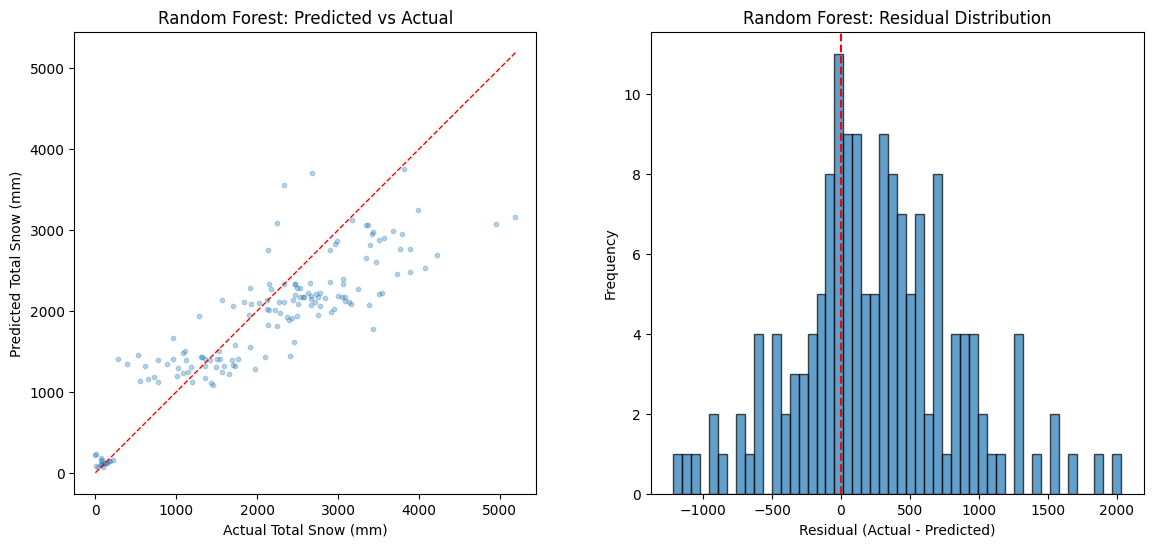


Best model: Random Forest
Mean residual: 254.85
Std residual: 580.99


In [ ]:
# best model based on test RMSE
best_model_name = results_df.index[0]
best_preds = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# scatterplot predicted vs actual
ax = axes[0]
ax.scatter(y_test, best_preds, alpha = 0.3, s = 10)
max_val = max(y_test.max(), best_preds.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth = 1)
ax.set_xlabel('Actual Total Snow (mm)')
ax.set_ylabel('Predicted Total Snow (mm)')
ax.set_title(f'{best_model_name}: Predicted vs Actual')
ax.set_aspect('equal')

# residual distribution histogram
ax = axes[1]
residuals = y_test - best_preds
ax.hist(residuals, bins = 50, edgecolor = 'black', alpha = 0.7)
ax.axvline(0, color = 'r', linestyle = '--')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title(f'{best_model_name}: Residual Distribution')
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual: {residuals.std():.2f}")

# Trend Analysis

Winter 2009: 2/4 regions have data, keeping.
Regional Snowfall Trend Analysis
Region 0 – Southern VT:
OLS slope: -59.7 mm/year  (p=0.0766)
R^2: 0.222
Kendall tau: -0.486  (p=0.0114)
Significant at alpha=0.05? no

Region 1 – Central VT:
OLS slope: 33.7 mm/year  (p=0.3510)
R^2: 0.067
Kendall tau: 0.029  (p=0.9226)
Significant at alpha=0.05? no

Region 2 – Northern VT:
OLS slope: -10.7 mm/year  (p=0.6608)
R^2: 0.014
Kendall tau: -0.100  (p=0.6259)
Significant at alpha=0.05? no

Region 3 – NEK / Border:
OLS slope: -41.6 mm/year  (p=0.2106)
R^2: 0.109
Kendall tau: -0.183  (p=0.3502)
Significant at alpha=0.05? no



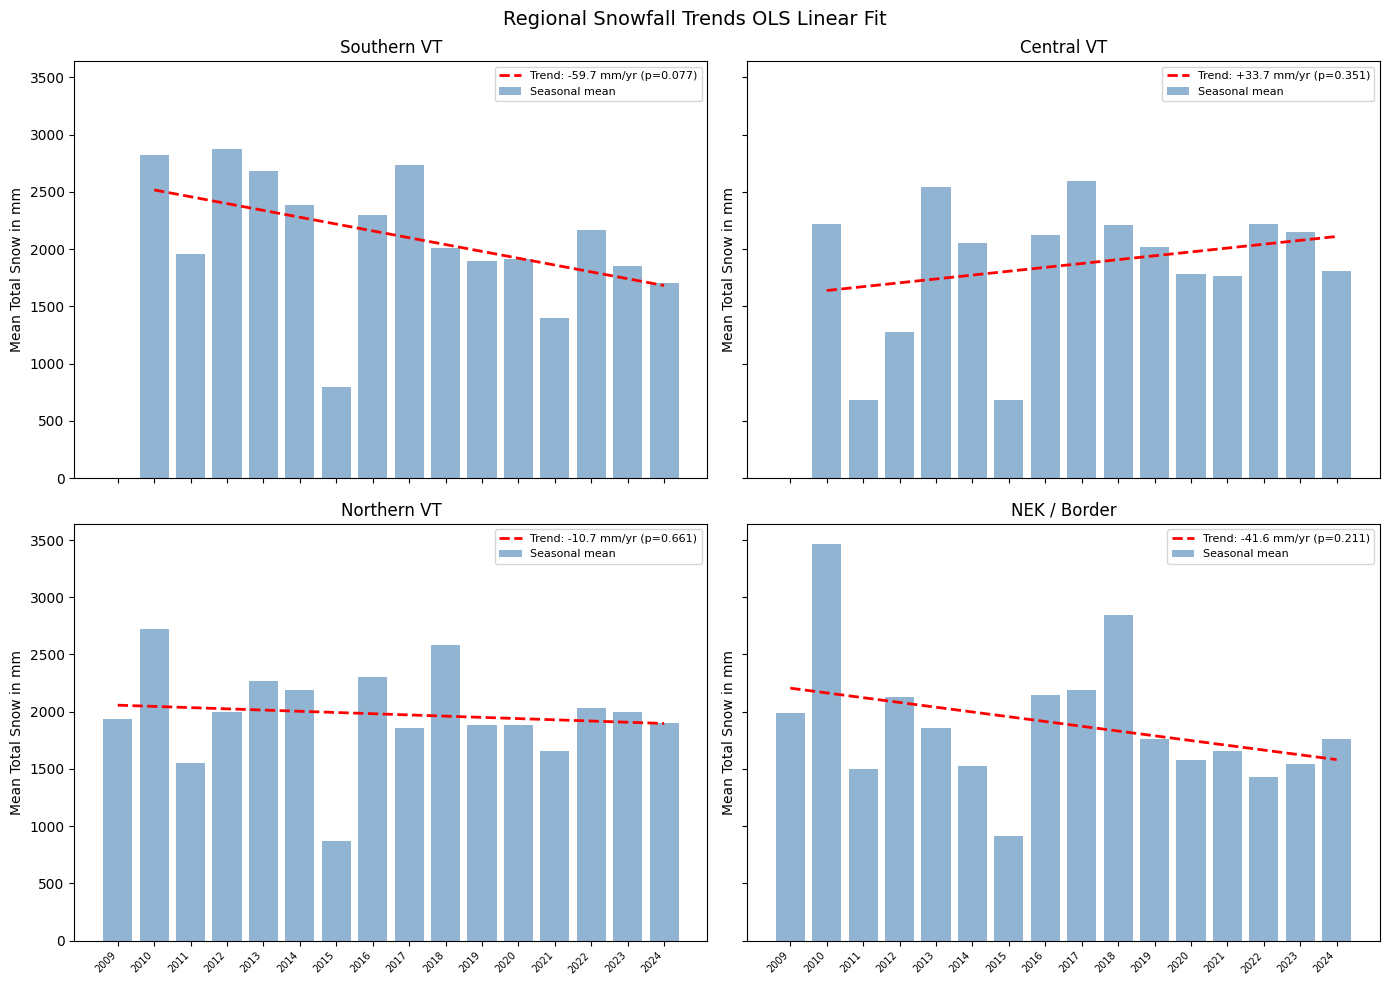

In [ ]:
# Per region Snowfall Trends
# OLS linear trend slope in mm/year with p value
# Mann Kendall trend test
# For each of the 4 regions, we test whether snowfall is
# increasing/decreasing over time using
#  OLS Linear Regression (stats.linregress):
#    Fits a straight line through (year, mean_snowfall)
#    The slope tells us mm of snowfall gained/lost per year
#    p-value < 0.05 means the trend is statistically significant
#    R^2 tells us how much of the variance the linear trend explains
# Kendall Tau (stats.kendalltau):
#    A nonparametric rank correlation test, checks whether
#    snowfall trends up/down over time without assuming
#    the relationship is linear, Tau ranges from -1 to +1


# Compute regional averages, for each region and winter_year
# average across all stations in that region
# Regional seasonal averages
regional_stats = seasonal_stats.groupby(['region', 'county_region_name', 'winter_year']).agg(
    mean_total_snow = ('total_snow', 'mean'),
    mean_snow_days = ('snow_days', 'mean'),
    mean_snow_season_days = ('snow_season_days', 'mean'),
    mean_snow_prcp_ratio = ('snow_prcp_ratio', 'mean'),
    n_stations = ('STATION', 'nunique'),
).reset_index()

# Check if 2009 has data for a majority of regions; if not, exclude it
n_total_regions = len(COUNTY_REGION_NAMES)
regions_with_2009 = regional_stats[regional_stats['winter_year'] == 2009]['region'].nunique()
if regions_with_2009 < (n_total_regions / 2):
    print(f"Winter 2009: only {regions_with_2009}/{n_total_regions} regions have data, excluding.")
    regional_stats = regional_stats[regional_stats['winter_year'] >= 2010].copy()
    min_plot_year = 2010
else:
    print(f"Winter 2009: {regions_with_2009}/{n_total_regions} regions have data, keeping.")
    min_plot_year = regional_stats['winter_year'].min()


print("Regional Snowfall Trend Analysis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()
all_years = sorted(regional_stats['winter_year'].unique())


for idx, (region_id, region_name) in enumerate(sorted(COUNTY_REGION_NAMES.items())):
    subset = regional_stats[regional_stats['region'] == region_id].copy()
    subset = subset.sort_values('winter_year')

    if len(subset) < 5:
        print(f"  Region {region_id} ({region_name}): too few data points for trend\n")
        continue

    x = subset['winter_year'].values.astype(float)
    y = subset['mean_total_snow'].values

    # OLS linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Mann Kendall
    try:
        mk_result = stats.kendalltau(x, y)
        mk_tau = mk_result.statistic
        mk_p = mk_result.pvalue
    except Exception:
        mk_tau, mk_p = float('nan'), float('nan')

    print(f"Region {region_id} – {region_name}:")
    print(f"OLS slope: {slope:.1f} mm/year  (p={p_value:.4f})")
    print(f"R^2: {r_value**2:.3f}")
    print(f"Kendall tau: {mk_tau:.3f}  (p={mk_p:.4f})")
    sig = "YES" if p_value < 0.05 else "no"
    print(f"Significant at alpha=0.05? {sig}\n")

    # Plot
    ax = axes[idx]
    ax.bar(subset['winter_year'], y,
           alpha = 0.6, color = 'steelblue', label = 'Seasonal mean')
    ax.plot(x, intercept + slope * x, 'r--', linewidth=2,
            label=f'Trend: {slope:+.1f} mm/yr (p={p_value:.3f})')
    ax.set_title(f'{region_name}', fontsize=12)
    ax.set_ylabel('Mean Total Snow in mm')
    ax.legend(fontsize = 8)
    ax.set_xticks(all_years)
    ax.set_xticklabels([str(y) for y in all_years], rotation=45, ha='right', fontsize=7)


plt.suptitle('Regional Snowfall Trends OLS Linear Fit', fontsize=14)
plt.tight_layout()
plt.show()

# Future Forecasting/predictions

Regional Snowfall Forecasts Next 5 Seasons
 region  forecast_year  mean_predicted_snow  std_predicted_snow  n_stations
      0           2025          1927.326955          934.362744          14
      0           2026          1926.386031          841.093978          14
      0           2027          2018.216019          897.125820          14
      0           2028          2017.963093          899.725257          14
      0           2029          2052.260001          902.597403          14
      1           2025          2003.173750          973.672961           7
      1           2026          2071.137247          914.306514           7
      1           2027          2076.852665          918.142146           7
      1           2028          2053.135902          940.702000           7
      1           2029          2061.644755          951.741064           7
      2           2025          2130.869273          973.909333          26
      2           2026          2104.676186  

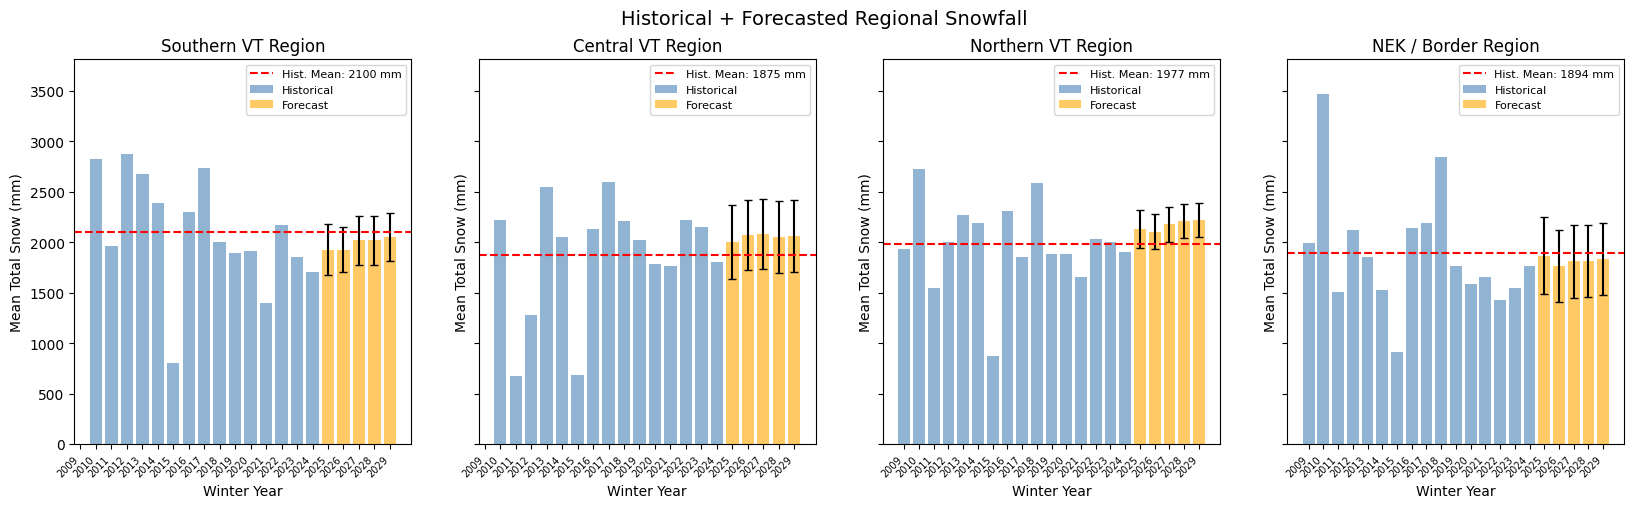

In [ ]:
# 1 Retrain the Random Forest on ALL available data (not just training set)
#   to maximize the information available for forecasting
# 2 For each station, start from its last known winter's features
# 3 Predict next winter's snowfall. Then use that prediction
#   to update the lag features, and predict the following winter
#   Repeat for 5 years.

# Key challenge: the model also uses precipitation, snow_days, and
# snow/prcp ratio as lag features, but we only predict snowfall
# Solution: estimate prcp and snow_days from the predicted snowfall
# using per station historical scaling factors (median ratios)

# regional historical stats for plotting
regional_stats = seasonal_stats.groupby(['region', 'winter_year']).agg(
    total_snow=('total_snow', 'mean'),
    total_prcp=('total_prcp', 'mean'),
    snow_days=('snow_days', 'mean'),
    n_stations=('STATION', 'nunique'),
).reset_index()

# upcoming 5 seasons
# forecasting we retrain best tree based model on all data
# project forward by incrementing year_numeric and using last known lags
best_model_for_forecast = RandomForestRegressor(
    n_estimators = 200, max_depth = 15, min_samples_leaf = 5,
    random_state = 42, n_jobs = -1
)
best_model_for_forecast.fit(
    ml_ready[FEATURE_COLS].values,
    ml_ready[TARGET_COL].values
)

# For each station grab the most recent winter's row, this row
# contains the lag features that seed the first forecast year
# last known data per station for bootstrapping forecasts
last_known = ml_ready.sort_values('winter_year').groupby('STATION').last().reset_index()

# Use a single global max year so all forecasts start at the same point
# This prevents per-station variation from causing forecast bars to
# overlap with historical bars
global_max_year = ml_ready['winter_year'].max()
global_min_year = ml_ready['winter_year'].min()

# Since we only predict total_snow, we need to estimate what
# prcp and snow_days would be for that predicted snow amount
# For each station, compute:
#   prcp_scale = median(total_prcp) / median(total_snow)
#     -> predicted_prcp = predicted_snow * prcp_scale
#   snow_days_scale = median(snow_days) / median(total_snow)
#     -> predicted_snow_days = predicted_snow * snow_days_scale
# Using medians (not means) makes these robust to outlier years
# Per station scaling factors for estimating non-snow lags from predicted snow
station_history = ml_ready.groupby('STATION').agg(
    median_prcp=('total_prcp', 'median'),
    median_snow=('total_snow', 'median'),
    median_snow_days=('snow_days', 'median'),
).reset_index()
# Divide median prcp by median snow
# Replace 0 snow with NaN to avoid division by
# zero then fill NaN with the global median scale factor
station_history['prcp_scale'] = (
    station_history['median_prcp'] /
    station_history['median_snow'].replace(0, np.nan)
).fillna((station_history['median_prcp'] / station_history['median_snow'].replace(0, np.nan)).median())
station_history['snow_days_scale'] = (
    station_history['median_snow_days'] /
    station_history['median_snow'].replace(0, np.nan)
).fillna((station_history['median_snow_days'] / station_history['median_snow'].replace(0, np.nan)).median())


forecast_years = 5
all_forecasts = []

# year updates lags from previous prediction
current_state = last_known.merge(
    station_history[['STATION', 'prcp_scale', 'snow_days_scale']],
    on='STATION', how='left'
)

# For computing snow_roll5, we need the last 5 actual snow values per station
# We store them in a dictionary: {station_id: [list of up to 5 values]}
# Each forecast iteration appends the predicted value and pops the oldest
# Initialize 5-year snow history buffer per station for proper roll5
snow_history = {}
for station in last_known['STATION'].values:
    station_data = ml_ready[
        ml_ready['STATION'] == station
    ].sort_values('winter_year')['total_snow'].values
    snow_history[station] = list(station_data[-5:])


# Recursive Forecast Loop
# For each of the next 5 years
#   1 Set the year forward (winter_year and year_numeric)
#   2 Run the model to get predicted snowfall
#   3 Update ALL lag features for the next iteration
for yr_offset in range(1, forecast_years + 1):
    forecast_rows = current_state.copy()
    # Advance the year counters by yr_offset from the last known year.
    forecast_rows['winter_year'] = global_max_year + yr_offset
    forecast_rows['year_numeric'] = (global_max_year + yr_offset) - global_min_year

    # Run the model: extract feature columns and predict
    X_forecast = forecast_rows[FEATURE_COLS].values
    predicted = best_model_for_forecast.predict(X_forecast)
    forecast_rows['predicted_snow'] = predicted
    forecast_rows['forecast_year'] = forecast_rows['winter_year']

    all_forecasts.append(forecast_rows[['STATION', 'NAME', 'region',
                                         'forecast_year', 'predicted_snow',
                                         'latitude', 'longitude', 'elevation']])
    # Shift the memory forward: what was lag1 becomes lag2, lag2 becomes lag3
    # The new prediction fills lag1, this mimics how real time would pass
    # Shift lags for next iteration: lag1 <- predicted, lag2 <- old lag1, lag3 <- old lag2
    current_state['snow_lag3'] = current_state['snow_lag2']
    current_state['snow_lag2'] = current_state['snow_lag1']
    current_state['snow_lag1'] = predicted

    # Estimate prcp from predicted snow using per-station scaling, then shift
    estimated_prcp = predicted * current_state['prcp_scale'].values
    current_state['prcp_lag3'] = current_state['prcp_lag2']
    current_state['prcp_lag2'] = current_state['prcp_lag1']
    current_state['prcp_lag1'] = estimated_prcp

    # Estimate snow_days from predicted snow, then shift
    estimated_snow_days = predicted * current_state['snow_days_scale'].values
    current_state['snow_days_lag3'] = current_state['snow_days_lag2']
    current_state['snow_days_lag2'] = current_state['snow_days_lag1']
    current_state['snow_days_lag1'] = estimated_snow_days

    # Derive ratio from estimates, then shift
    estimated_ratio = np.where(estimated_prcp > 0, predicted / estimated_prcp, 0)
    current_state['ratio_lag3'] = current_state['ratio_lag2']
    current_state['ratio_lag2'] = current_state['ratio_lag1']
    current_state['ratio_lag1'] = estimated_ratio

    # Append the predicted snow to each station's history buffer
    # Then compute roll3 (last 3 values) and roll5 (last 5 values)
    # as true means from the buffer, not approximations
    # Update snow history buffer and compute proper rolling averages
    for i, station in enumerate(current_state['STATION'].values):
        snow_history[station].append(predicted[i])
        if len(snow_history[station]) > 5:
            snow_history[station] = snow_history[station][-5:]

    current_state['snow_roll3'] = [
        np.mean(snow_history[s][-3:]) for s in current_state['STATION'].values
    ]
    current_state['snow_roll5'] = [
        np.mean(snow_history[s][-5:]) for s in current_state['STATION'].values
    ]

# Combine all 5 years of forecasts into one DataFrame
forecasts_df = pd.concat(all_forecasts, ignore_index=True)

# Regional forecast summary
regional_forecast = forecasts_df.groupby(['region', 'forecast_year']).agg(
    mean_predicted_snow=('predicted_snow', 'mean'),
    std_predicted_snow=('predicted_snow', 'std'),
    n_stations=('STATION', 'nunique'),
).reset_index()

print("Regional Snowfall Forecasts Next 5 Seasons")
print(regional_forecast.to_string(index=False))





# Compute historical mean per region (excludes forecast years)
hist_mean_by_region = regional_stats.groupby('region')['total_snow'].mean()

# Plot forecasts with historical data
n_regions = len(COUNTY_REGION_NAMES)

# compute shared y axis limit across all regions
y_max = max(
    regional_stats['total_snow'].max(),
    regional_forecast['mean_predicted_snow'].max()
) * 1.1

# Collect all years (historical + forecast) for explicit tick labels
all_plot_years = sorted(set(
    regional_stats['winter_year'].tolist() +
    regional_forecast['forecast_year'].tolist()
))


fig, axes = plt.subplots(1, n_regions, figsize = (5 * n_regions, 5), squeeze = False, sharey=True)
for i, region in enumerate(sorted(regional_stats['region'].unique())):
    ax = axes[0, i]

    # Historical data
    hist = regional_stats[regional_stats['region'] == region]
    ax.bar(hist['winter_year'], hist['total_snow'],
           alpha=0.6, label='Historical', color='steelblue')

    # Forecast
    fcast = regional_forecast[regional_forecast['region'] == region].copy()
    fcast['se_mean'] = fcast['std_predicted_snow'] / np.sqrt(fcast['n_stations'])
    ax.bar(fcast['forecast_year'], fcast['mean_predicted_snow'],
           alpha=0.6, label='Forecast', color='orange')
    ax.errorbar(fcast['forecast_year'], fcast['mean_predicted_snow'],
                yerr=fcast['se_mean'], fmt='none', color='black', capsize=3)

    # Historical mean line (computed from historical data only)
    region_mean = hist_mean_by_region[region]
    ax.axhline(y=region_mean, color='red', linestyle='--', linewidth=1.5,
               label=f'Hist. Mean: {region_mean:.0f} mm')

    ax.set_title(f'{COUNTY_REGION_NAMES[i]} Region')
    ax.set_xlabel('Winter Year')
    ax.set_ylabel('Mean Total Snow (mm)')
    ax.set_ylim(0, y_max)
    ax.legend(fontsize=8)
    # year tick labels
    ax.set_xticks(all_plot_years)
    ax.set_xticklabels([str(y) for y in all_plot_years], rotation=45, ha='right', fontsize=7)

plt.suptitle('Historical + Forecasted Regional Snowfall', fontsize=14)
#plt.tight_layout()
plt.show()